In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

In [ ]:
years = [2021.0, 2022.0, 2023.0]
boroughs = ['manhattan', 'brooklyn', 'bronx', 'queens']

borough_year_data = {}
for y in years:
    borough_year_data[y] = {}
    for b in boroughs:
        borough_year_data[y][b] = pd.read_csv(f"..\\Dataset\\NYC_DWT_Analysis\\{y}\\{b}.csv")

nta_gdf = gpd.read_file("..\\Dataset\\NYC_DWT_Analysis\\nynta2020_25d\\nynta2020.shp")
nta_gdf['NTA2020'] = nta_gdf["NTA2020"].astype(str).str.lower()

BOROUGH_COLORS = {
    "manhattan": "#e41a1c",
    "brooklyn":  "#377eb8",
    "bronx":     "#4daf4a",
    "queens":    "#ff7f00",
}

In [3]:
#NTA aggregation, just as before
nta_data = {}
for y in years:
    nta_data[y] = {}
    for b in boroughs:
        df = borough_year_data[y][b].copy()

        df["has_violation"] = (df["Violation_Code"] != '0').astype(int)
        df["is_audit"] = (df["Activity_Type"] == "nyc health department audit").astype(int)

        agg = df.groupby('NTA_Code').agg(   inspection_count = ("BIN", "count"),
                                            violation_count = ("has_violation", "sum"),
                                            total_dwt = ('Number of DWT', "sum"),
                                            audit_count = ("is_audit", "sum"), ).reset_index()

        agg["violation_rate"] = agg["violation_count"]/agg["inspection_count"]
        agg["avg_dwt"]        = agg["total_dwt"]/agg["inspection_count"]
        agg["audit_fraction"] = agg["audit_count"]/agg["inspection_count"]

        nta_data[y][b] = agg.drop(columns=["violation_count", "total_dwt", "audit_count"])

In [4]:
NTA_Prefix = {'bronx': 'bx', 'queens': 'qn', 'brooklyn': 'bk', 'manhattan': 'mn'}

geo_data = {}
for y in years:
    geo_data[y] = {}
    for b in boroughs:
        prefix = NTA_Prefix[b]
        borough_shape = nta_gdf[nta_gdf["NTA2020"].str.startswith(prefix)].copy()
        merged = borough_shape.merge(nta_data[y][b], left_on="NTA2020", right_on="NTA_Code", how="left")
        for col in ["inspection_count", "violation_rate", "avg_dwt", "audit_fraction"]:
            merged[col] = merged[col].fillna(0)
        geo_data[y][b] = merged.reset_index(drop=True)

In [5]:
validation_records = []
all_res = {}

for y in years:
    all_res[y] = {}
    for b in boroughs:
        gdf = geo_data[y][b].copy()
        gdf = gdf[gdf["inspection_count"] > 0].reset_index(drop=True)
        n   = len(gdf)

        if n < 10 or np.var(gdf["violation_rate"].values) == 0:
            print(f"  Skipping {b} {int(y)} — insufficient data ({n} NTAs)")
            continue

        rng  = np.random.default_rng(42)
        cx   = gdf.geometry.centroid.x.values
        cy   = gdf.geometry.centroid.y.values
        quad = (cx >= np.median(cx)).astype(int) * 2 + (cy >= np.median(cy)).astype(int)

        is_test = np.zeros(n, dtype=bool)
        for q in range(4):
            idx = np.where(quad == q)[0]
            if len(idx) == 0:
                continue
            k = max(1, round(len(idx) * 0.20))
            is_test[rng.choice(idx, size=k, replace=False)] = True

        tr_gdf = gdf[~is_test].reset_index(drop=True)
        te_gdf = gdf[ is_test].reset_index(drop=True)

        if len(tr_gdf) < 8 or len(te_gdf) < 2:
            print(f"  Skipping {b} {int(y)} — split too small")
            continue

        tr_proj  = tr_gdf.to_crs(epsg=32618)
        c_tr     = np.column_stack([tr_proj.geometry.centroid.x, tr_proj.geometry.centroid.y])
        y_tr     = tr_gdf["violation_rate"].values.reshape(-1, 1)
        X_tr     = np.column_stack([tr_gdf["avg_dwt"].values, tr_gdf["inspection_count"].values, tr_gdf["audit_fraction"].values])

        bw = None
        for bw_min_attempt in range(5, len(tr_gdf) // 2, 3):
            try:
                selector = Sel_BW(c_tr, y_tr, X_tr, fixed=False)
                bw = int(selector.search(criterion="AICc", bw_min=bw_min_attempt, bw_max=len(tr_gdf) - 1))
                break
            except (np.linalg.LinAlgError, ValueError):
                continue

        if bw is None:
            print(f"  Skipping {b} {int(y)} — BW selection singular at all starting points")
            continue

        print(f"  {b} {int(y)} — n_train={len(tr_gdf)}, n_test={len(te_gdf)}, bw={bw}")

        gwr_fit = None
        for bw_attempt in range(bw, len(tr_gdf), 2):
            try:
                gwr_fit = GWR(c_tr, y_tr, X_tr, bw_attempt, fixed=False, kernel="bisquare").fit()
                if bw_attempt != bw:
                    print(f"    Singular at bw={bw}, succeeded at bw={bw_attempt}")
                bw = bw_attempt
                break
            except (np.linalg.LinAlgError, ValueError):
                continue

        if gwr_fit is None:
            print(f"  Skipping {b} {int(y)} — singular at all bandwidths")
            continue

        te_proj = te_gdf.to_crs(epsg=32618)
        c_te = np.column_stack([te_proj.geometry.centroid.x, te_proj.geometry.centroid.y])
        X_te = np.column_stack([te_gdf["avg_dwt"].values, te_gdf["inspection_count"].values, te_gdf["audit_fraction"].values])
        Xb_tr = np.column_stack([np.ones(len(X_tr)), X_tr])

        y_pred_te = np.zeros(len(te_gdf))
        for i in range(len(c_te)):
            dists = np.sqrt(np.sum((c_tr - c_te[i]) ** 2, axis=1))
            h_i = np.sort(dists)[min(bw, len(dists) - 1)]
            u = dists / (h_i + 1e-9)
            w = np.where(u < 1, (1 - u ** 2) ** 2, 0.0)
            W = np.diag(w)
            A = Xb_tr.T @ W @ Xb_tr
            rhs = Xb_tr.T @ W @ y_tr
            try:
                beta_local = np.linalg.solve(A, rhs)
            except np.linalg.LinAlgError:
                beta_local = np.linalg.lstsq(A, rhs, rcond=None)[0]
            x_star = np.array([1.0, X_te[i, 0], X_te[i, 1], X_te[i, 2]])
            y_pred_te[i] = float(x_star @ beta_local)

        y_true_te = te_gdf["violation_rate"].values
        y_true_tr = tr_gdf["violation_rate"].values
        y_pred_tr = gwr_fit.predy.flatten()

        ss_res_tr = np.sum((y_true_tr - y_pred_tr) ** 2)
        ss_tot_tr = np.sum((y_true_tr - y_true_tr.mean()) ** 2)
        ss_res_te = np.sum((y_true_te - y_pred_te) ** 2)
        ss_tot_te = np.sum((y_true_te - y_true_te.mean()) ** 2)

        train_RMSE = round(float(np.sqrt(np.mean((y_true_tr - y_pred_tr) ** 2))), 5)
        test_RMSE  = round(float(np.sqrt(np.mean((y_true_te - y_pred_te) ** 2))), 5)
        train_MAE  = round(float(np.mean(np.abs(y_true_tr - y_pred_tr))), 5)
        test_MAE   = round(float(np.mean(np.abs(y_true_te - y_pred_te))), 5)
        train_R2   = round(float(1 - ss_res_tr / ss_tot_tr) if ss_tot_tr > 0 else float("nan"), 4)
        test_R2    = round(float(1 - ss_res_te / ss_tot_te) if ss_tot_te > 0 else float("nan"), 4)

        print(f"    train R²={train_R2:.3f}  test R²={test_R2:.3f}  test RMSE={test_RMSE:.4f}")

        validation_records.append({"year": int(y), "borough": b, "n_train": len(tr_gdf), "n_test": len(te_gdf), "bw": bw,
                                   "train_RMSE": train_RMSE, "test_RMSE": test_RMSE,
                                   "train_MAE":  train_MAE,  "test_MAE":  test_MAE,
                                   "train_R2":   train_R2,   "test_R2":   test_R2})
        all_res[y][b] = {"gdf": gdf, "tr_gdf": tr_gdf, "te_gdf": te_gdf,
                         "y_true_te": y_true_te, "y_pred_te": y_pred_te,
                         "y_true_tr": y_true_tr, "y_pred_tr": y_pred_tr}

val_df = pd.DataFrame(validation_records)

  manhattan 2021 — n_train=27, n_test=8, bw=25
    train R²=0.298  test R²=-15.983  test RMSE=0.0766
  brooklyn 2021 — n_train=35, n_test=10, bw=33
    train R²=0.557  test R²=-0.355  test RMSE=0.2082
  Skipping bronx 2021 — BW selection singular at all starting points
  Skipping queens 2021 — BW selection singular at all starting points
  manhattan 2022 — n_train=27, n_test=8, bw=25
    train R²=0.247  test R²=-1.075  test RMSE=0.0285
  brooklyn 2022 — n_train=35, n_test=10, bw=33
    train R²=0.194  test R²=-9.158  test RMSE=0.3512
  bronx 2022 — n_train=28, n_test=8, bw=26
    train R²=0.219  test R²=-3.862  test RMSE=0.1716
  queens 2022 — n_train=30, n_test=8, bw=28
    train R²=0.060  test R²=-5.987  test RMSE=0.0464
  manhattan 2023 — n_train=27, n_test=8, bw=25
    train R²=0.054  test R²=-2.951  test RMSE=0.0543
  brooklyn 2023 — n_train=36, n_test=10, bw=28
    train R²=0.587  test R²=-0.716  test RMSE=0.1450
  bronx 2023 — n_train=29, n_test=8, bw=27
    train R²=0.225  test

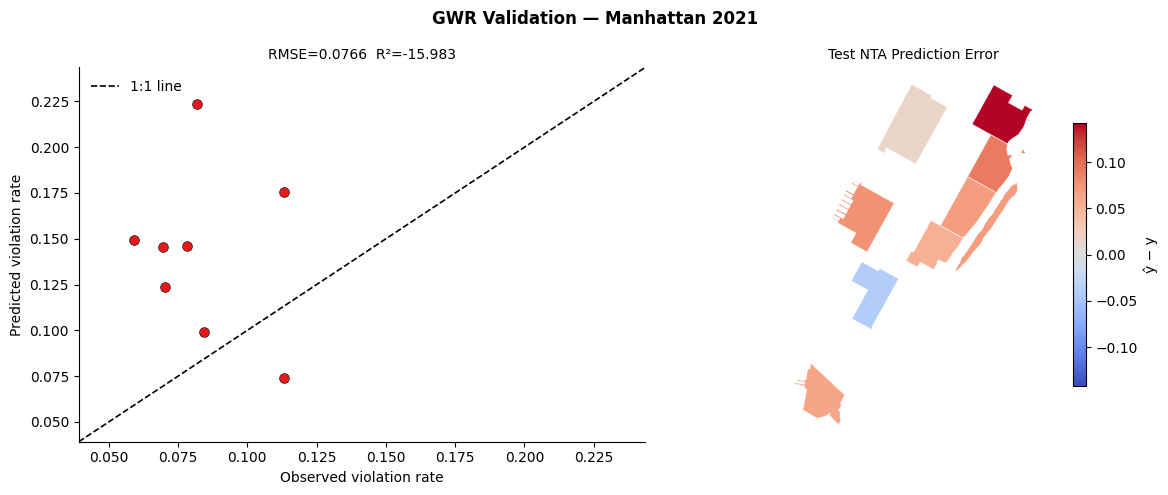

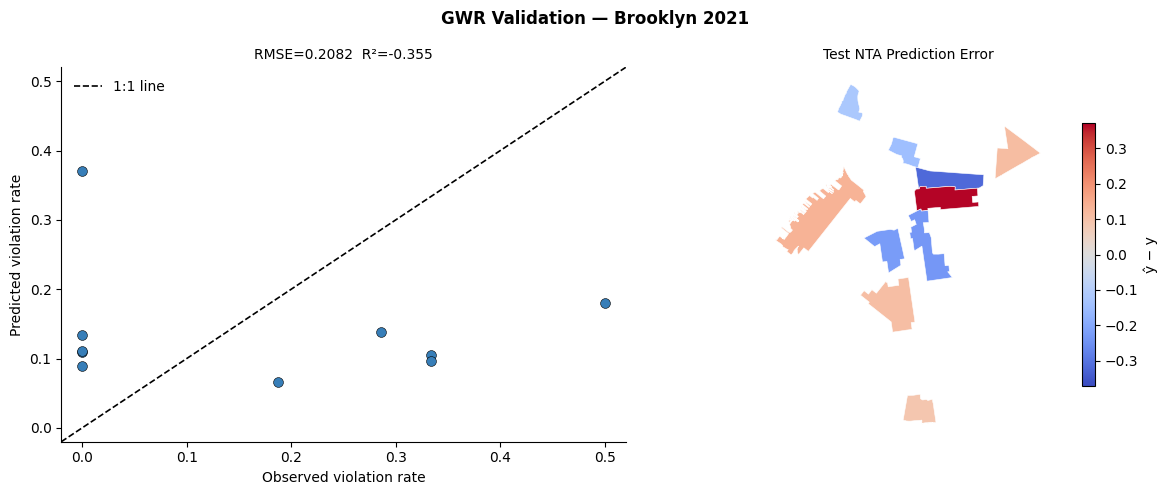

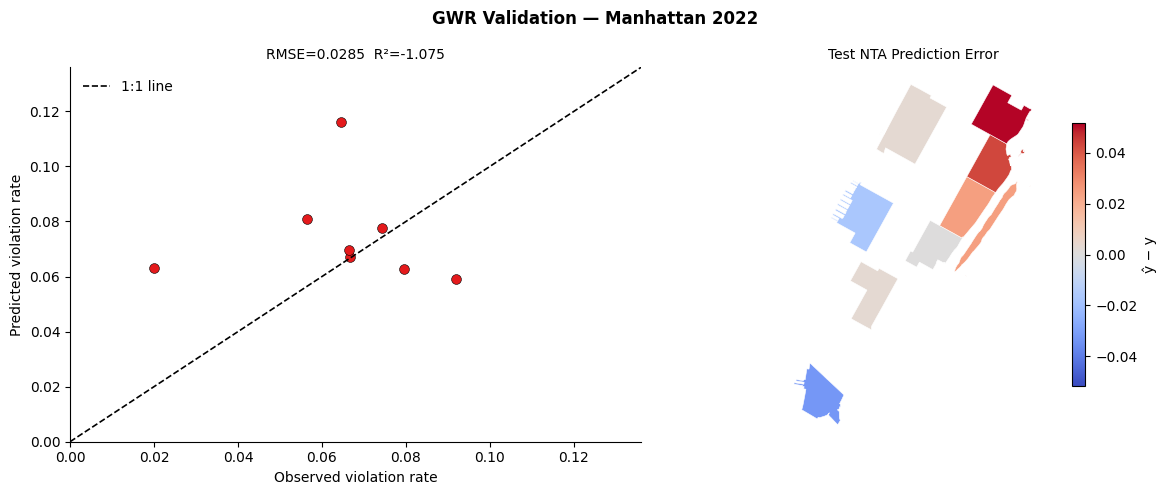

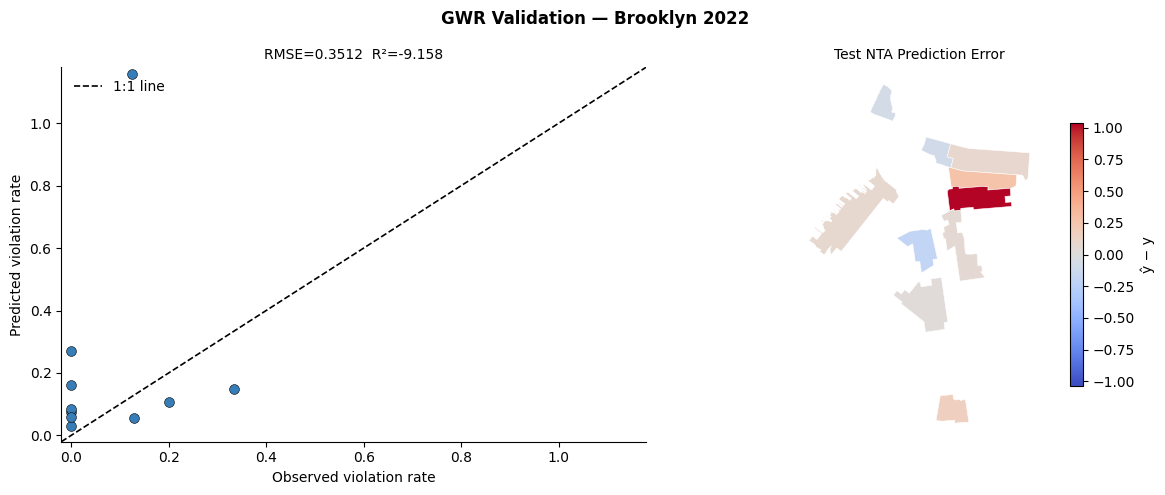

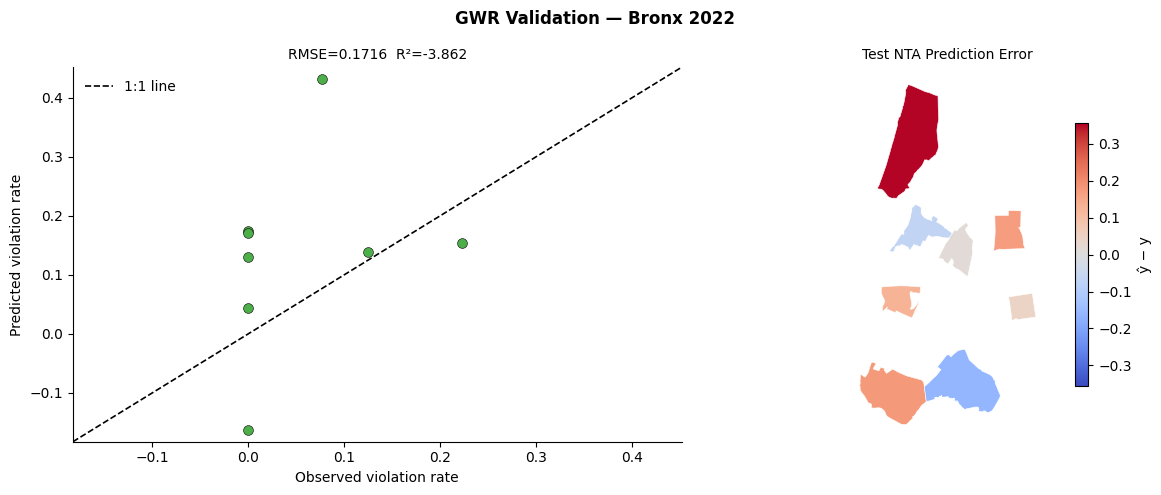

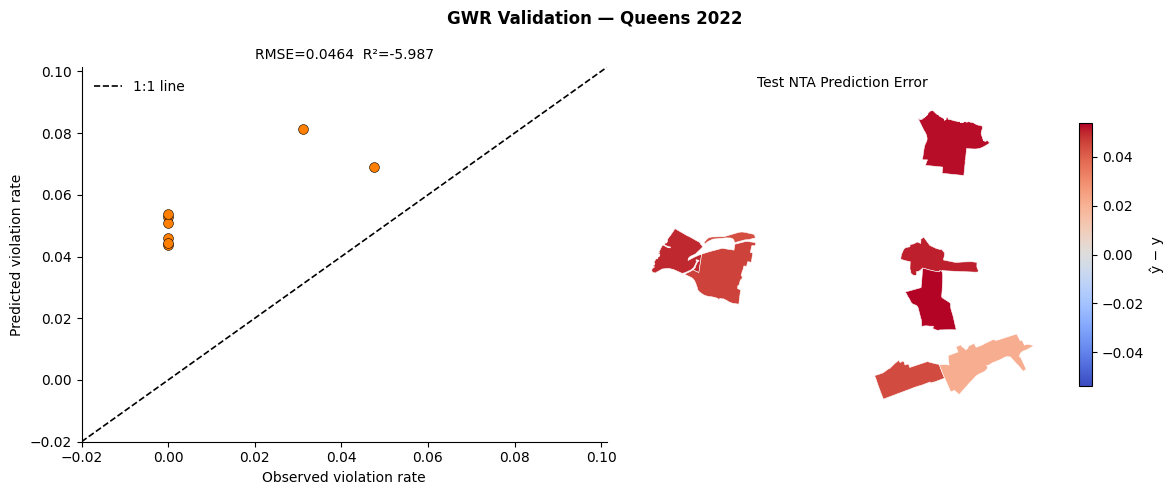

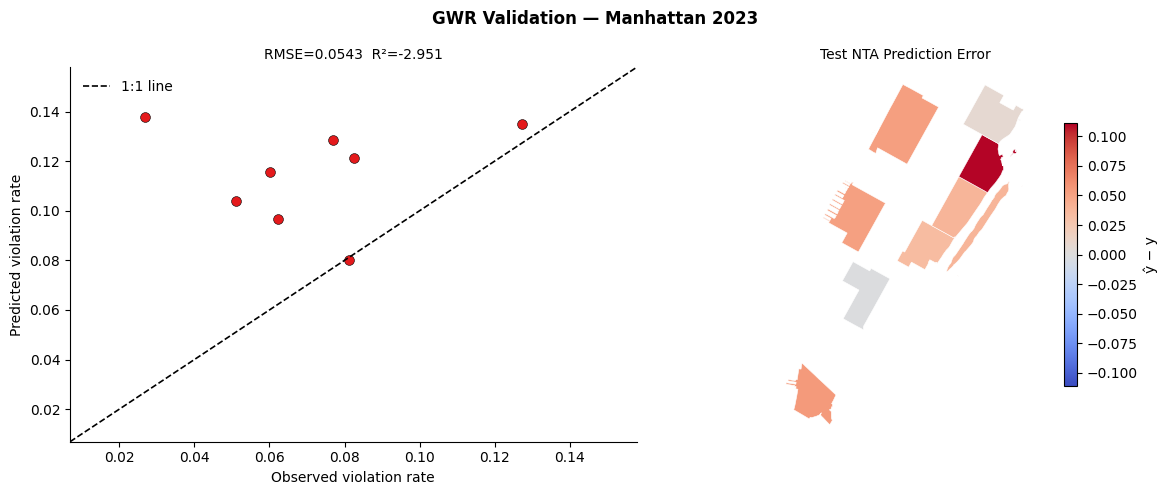

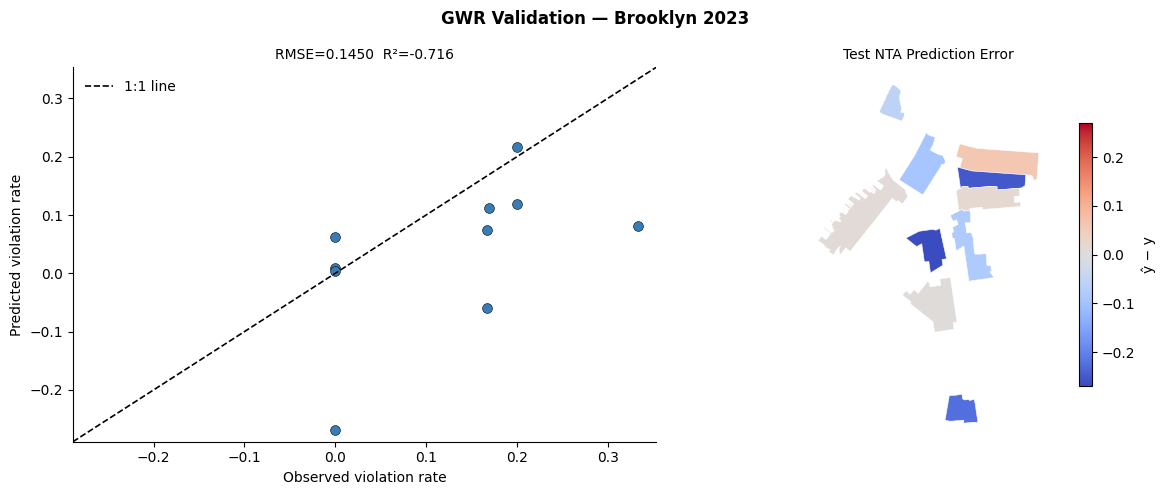

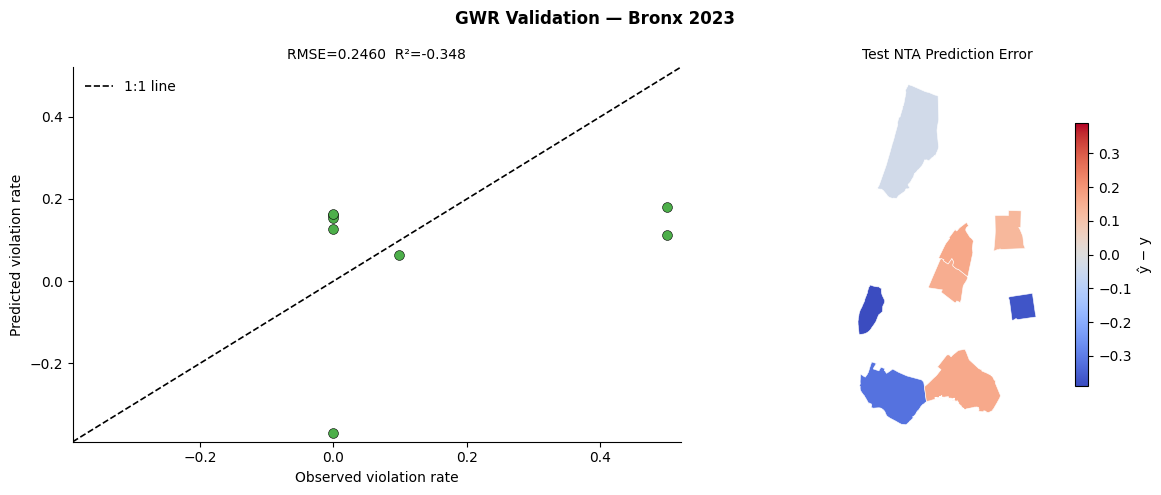

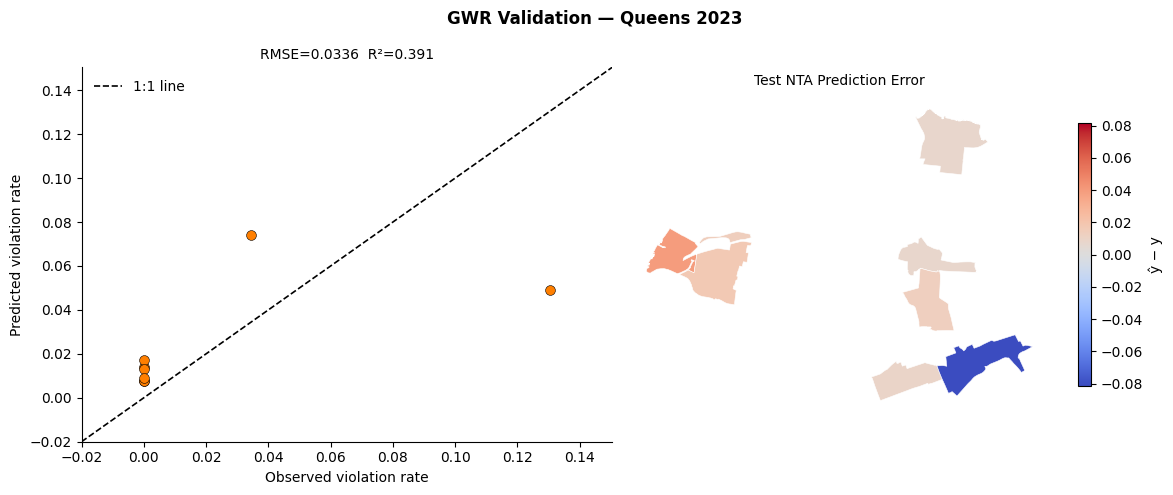

In [7]:
#Validation plots: predicted vs actual scatter and test error choropleth
for y in years:
    for b in boroughs:
        if b not in all_res[y]:
            continue

        te_gdf   = all_res[y][b]["te_gdf"]
        y_true   = all_res[y][b]["y_true_te"]
        y_pred   = all_res[y][b]["y_pred_te"]

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"GWR Validation — {b.title()} {int(y)}", fontsize=12, fontweight="bold")

        lo = min(y_true.min(), y_pred.min()) - 0.02
        hi = max(y_true.max(), y_pred.max()) + 0.02
        axes[0].scatter(y_true, y_pred, color=BOROUGH_COLORS[b], edgecolors="black", linewidths=0.4, s=50)
        axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1.2, label="1:1 line")
        rec = val_df[(val_df["year"] == int(y)) & (val_df["borough"] == b)].iloc[0]
        axes[0].set_title(f"RMSE={rec.test_RMSE:.4f}  R²={rec.test_R2:.3f}", fontsize=10)
        axes[0].set_xlabel("Observed violation rate")
        axes[0].set_ylabel("Predicted violation rate")
        axes[0].set_xlim(lo, hi); axes[0].set_ylim(lo, hi)
        axes[0].legend(frameon=False)
        axes[0].spines[["top", "right"]].set_visible(False)

        err_gdf = te_gdf.copy()
        err_gdf["pred_error"] = y_pred - y_true
        abs_max = max(float(np.abs(err_gdf["pred_error"]).max()), 1e-6)
        err_gdf.plot(column="pred_error", cmap="coolwarm", vmin=-abs_max, vmax=abs_max,
                     edgecolor="white", linewidth=0.4, legend=True, ax=axes[1],
                     legend_kwds={"label": "ŷ − y", "shrink": 0.7})
        axes[1].set_title("Test NTA Prediction Error", fontsize=10)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()